In [2]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [3]:
#Load Dataset
df  = pd.read_csv("earthquake_data_tsunami.csv")
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [5]:
# Data Cleaning
df.isnull().sum()

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

In [6]:
df = df.fillna(df.mean(numeric_only=True))

In [7]:
df.duplicated().sum()

np.int64(0)

In [40]:
df = df.drop_duplicates()

C:\Users\hp367\AppData\Local\Temp\ipykernel_30548\481316708.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


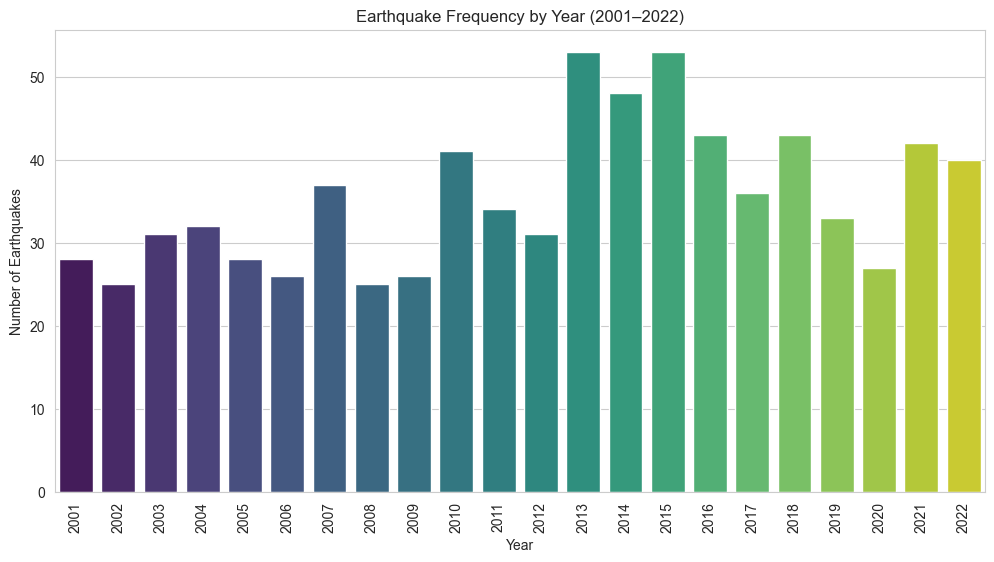

In [43]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="Year",
    data=df,
    palette="viridis"
)

plt.xticks(rotation=90)
plt.title("Earthquake Frequency by Year (2001–2022)")
plt.xlabel("Year")
plt.ylabel("Number of Earthquakes")

plt.show()

C:\Users\hp367\AppData\Local\Temp\ipykernel_30548\719267626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


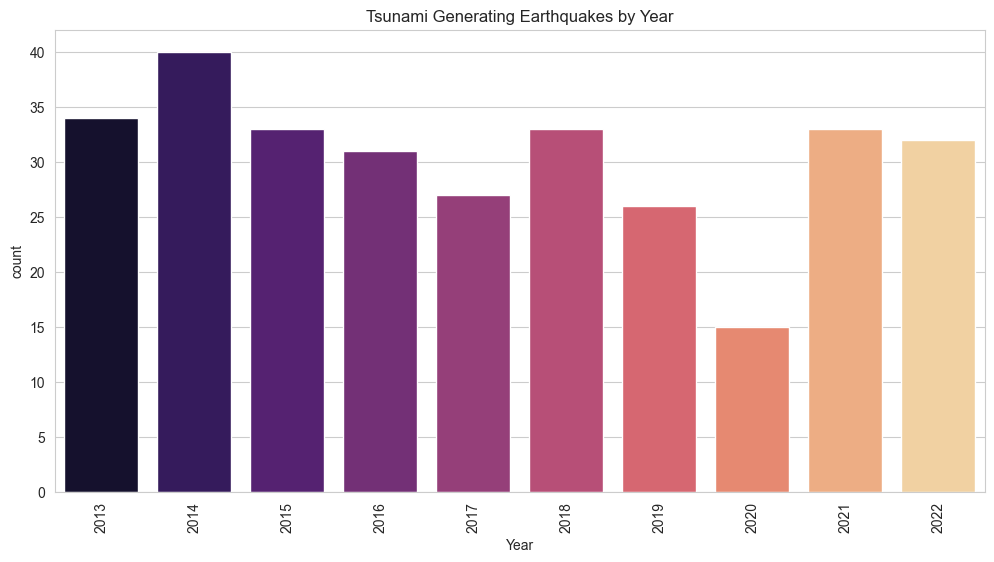

In [44]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="Year",
    data=df[df["tsunami"]==1],
    palette="magma"
)

plt.xticks(rotation=90)
plt.title("Tsunami Generating Earthquakes by Year")

plt.show()

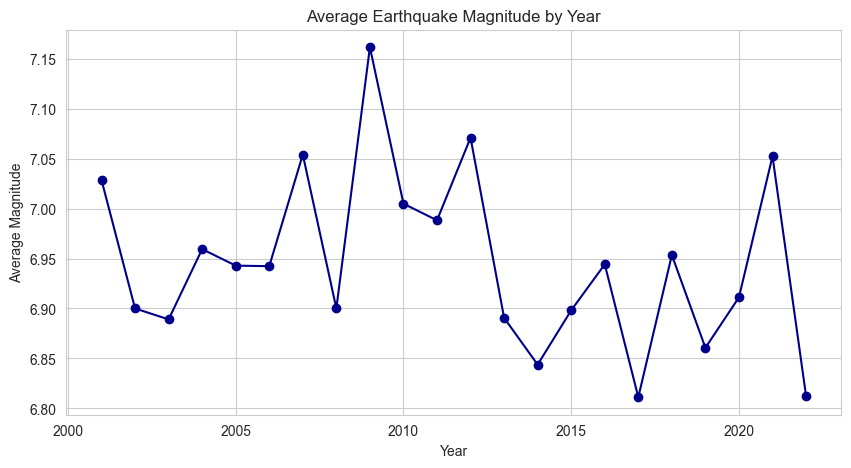

In [45]:
avg_mag = df.groupby("Year")["magnitude"].mean()

plt.figure(figsize=(10,5))

avg_mag.plot(
    marker="o",
    color="darkblue"
)

plt.title("Average Earthquake Magnitude by Year")
plt.xlabel("Year")
plt.ylabel("Average Magnitude")

plt.show()

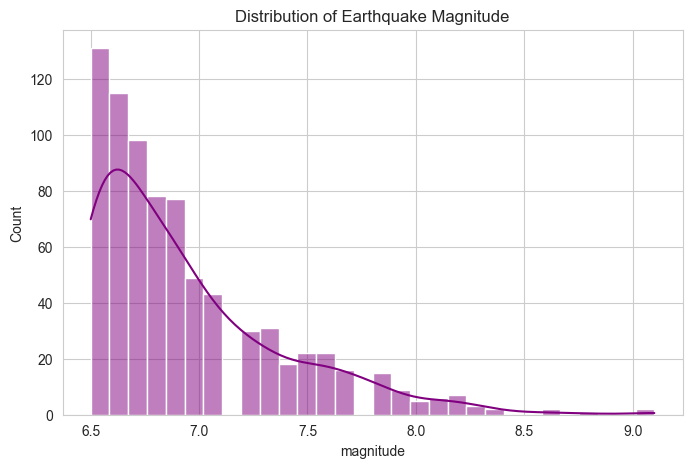

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["magnitude"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribution of Earthquake Magnitude")

plt.show()

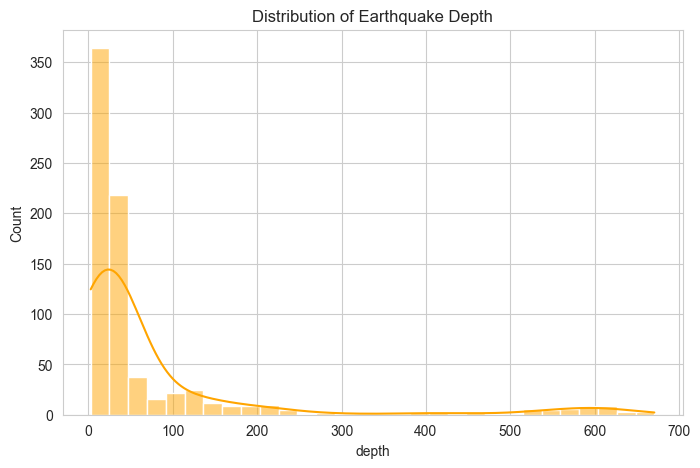

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["depth"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Earthquake Depth")

plt.show()

C:\Users\hp367\AppData\Local\Temp\ipykernel_30548\3002883631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


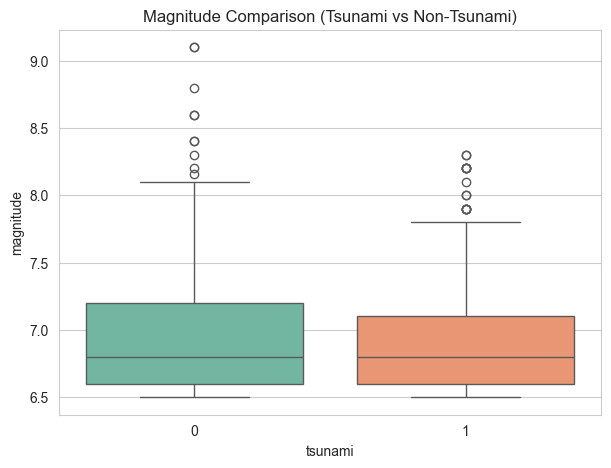

In [48]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="tsunami",
    y="magnitude",
    data=df,
    palette="Set2"
)

plt.title("Magnitude Comparison (Tsunami vs Non-Tsunami)")

plt.show()

C:\Users\hp367\AppData\Local\Temp\ipykernel_30548\1489169182.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


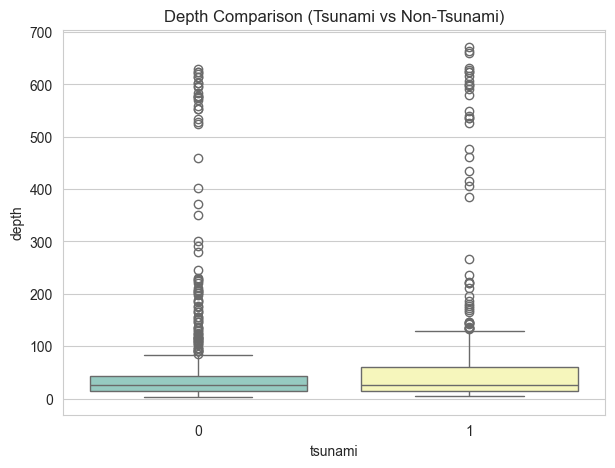

In [49]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="tsunami",
    y="depth",
    data=df,
    palette="Set3"
)

plt.title("Depth Comparison (Tsunami vs Non-Tsunami)")

plt.show()

In [50]:
major_eq = df[df["magnitude"] >= 8]

major_eq[["Year","magnitude","depth","tsunami"]]

,Year,magnitude,depth,tsunami
56,2021,8.10,22.79,0
59,2021,8.20,46.66,1
60,2021,8.20,35.00,1
74,2021,8.10,28.93,1
129,2019,8.00,122.57,1
170,2018,8.20,600.00,1
198,2017,8.20,47.39,1
285,2015,8.30,22.44,1
356,2014,8.20,25.00,1
393,2013,8.30,598.10,1


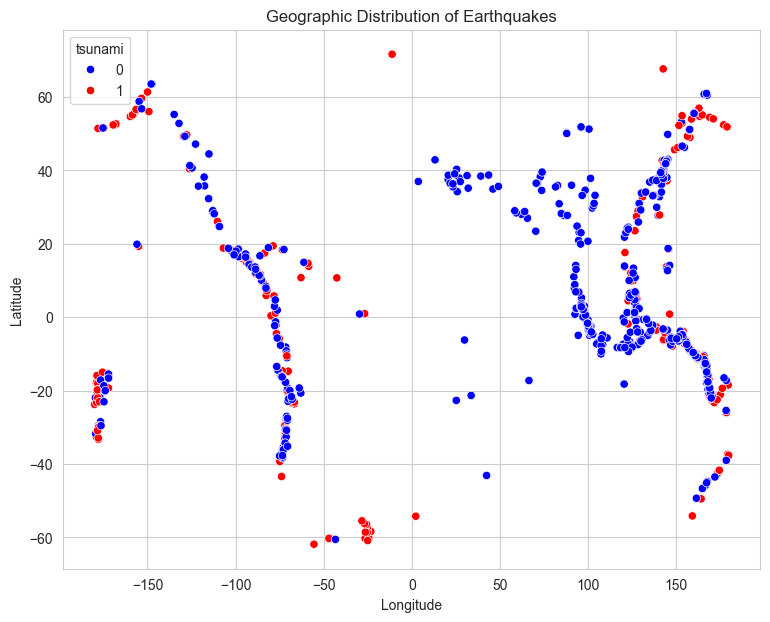

In [51]:
plt.figure(figsize=(9,7))

sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="tsunami",
    palette=["blue","red"],
    data=df
)

plt.title("Geographic Distribution of Earthquakes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

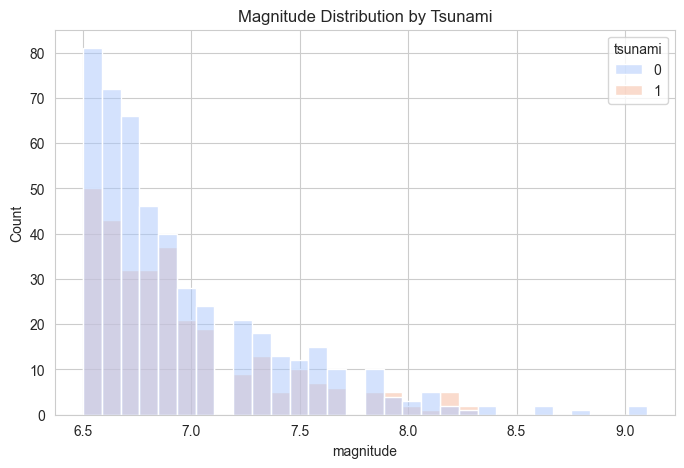

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="magnitude",
    hue="tsunami",
    bins=30,
    palette="coolwarm"
)

plt.title("Magnitude Distribution by Tsunami")

plt.show()

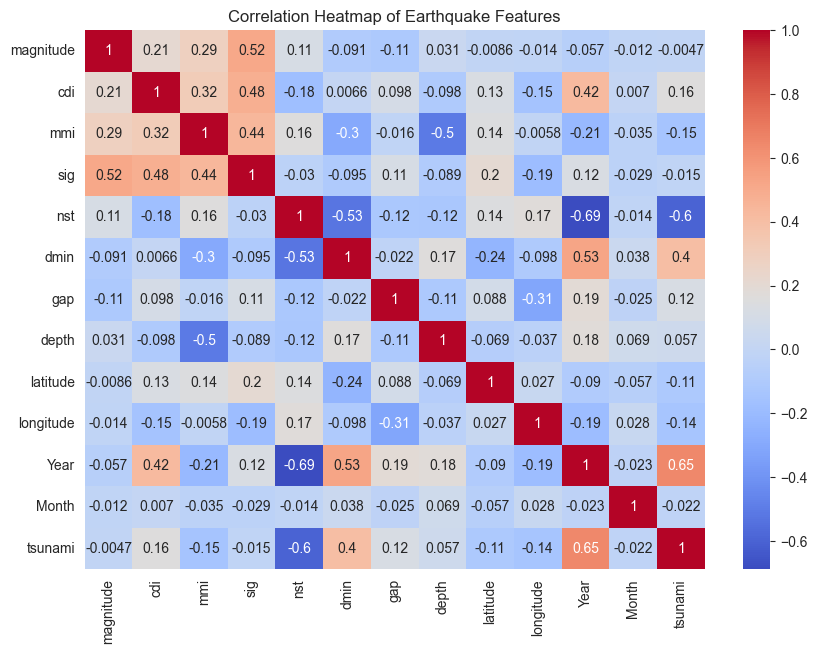

In [53]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Earthquake Features")

plt.show()

## Objective 5: Insights and Observations

### Key Insights

- Earthquake occurrences fluctuate across different years, indicating varying levels of seismic activity over time.

- Tsunami-generating earthquakes are relatively rare compared to the total number of earthquakes recorded in the dataset.

- Earthquakes with higher magnitudes tend to have a higher probability of generating tsunamis.

- The geographic scatter plot of latitude and longitude reveals clusters of earthquake activity in certain regions, suggesting tectonically active zones.

- Seismic characteristics such as magnitude and depth appear to influence the likelihood of tsunami generation.



### Final Conclusion

The exploratory data analysis of global earthquake data from 2001 to 2022 reveals important patterns in magnitude, depth, and geographic distribution of earthquakes. The analysis shows that tsunami-generating earthquakes generally have higher magnitudes and specific seismic characteristics compared to non-tsunami events. Visualization techniques such as histograms, box plots, scatter plots, and heatmaps help identify relationships between seismic variables and tsunami occurrence. These insights contribute to understanding seismic behavior and potential tsunami risks.